# Data-Driven Learning and Planning for Environmental Sampling

This notebook is a control panel for the OceanBench implementation of:

- paper-faithful SOGP (`sogp_paper`)
- SVGP GPyTorch baseline (`svgp_gpytorch`)
- MI planners (`mi_dp`, `mi_greedy`)
- Open-TSP routing backends (`ortools`, `networkx`, `python_tsp`)
- Static and dynamic truth modes

The top config dictionary controls all options. Re-run cells after changing config.

In [1]:
from __future__ import annotations

import copy
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd


def _find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for candidate in [p] + list(p.parents):
        if (candidate / "oceanbench-core").exists() and (candidate / "oceanbench-bench").exists():
            return candidate
    return p


REPO_ROOT = _find_repo_root(Path.cwd())

# OceanBench uses folder names with dashes (e.g. oceanbench-policies)
# while Python imports use underscores (e.g. oceanbench_policies).
# So each package directory must be on sys.path.
for pkg_dir in [
    "oceanbench-core",
    "oceanbench-env",
    "oceanbench-models",
    "oceanbench-tasks",
    "oceanbench-bench",
    "oceanbench-policies",
    "oceanbench-data-provider",
    "oceanbench-viz",
]:
    pkg_path = REPO_ROOT / pkg_dir
    if pkg_path.exists() and str(pkg_path) not in sys.path:
        sys.path.insert(0, str(pkg_path))

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from oceanbench_bench.runner import run_persistent_sampling
from oceanbench_viz import plot_map_sequence, plot_metric_curves, plot_route_sequence

print("Repo root:", REPO_ROOT)

Repo root: /home/shafezi/Documents/Projects/Data_Provider/oceanbench


In [2]:
# ------------------------------------------------------------------
# CONTROL PANEL: change options here
# ------------------------------------------------------------------
CONFIG = {
    "seed": 42,
    "scenario": {
        "name": "dlp_control_panel",
        "product_id": "copernicus_phy_reanalysis_001_030",
        "variable": "temp",
        "region": {
            "lat_min": 22.0,
            "lat_max": 28.0,
            "lon_min": -92.0,
            "lon_max": -86.0,
        },
        "time_window": ["2014-01-01T00:00:00", "2014-01-07T00:00:00"],
        "depth": None,
    },
    "candidates": {
        "type": "grid",                       # grid | random | graph
        "grid": {"n_lat": 40, "n_lon": 40},
        "max_points": 1600,
        "seed": 42,
        "subsample_strategy": "random",
    },
    "field_model": {
        "backend": "sogp_paper",             # sogp_paper | svgp_gpytorch
        "params": {
            "max_basis_size": 100,
            "novelty_threshold": 1e-6,
            "lengthscale": 1.0,
            "variance": 1.0,
            "include_time": True,
            "include_depth": False,
            "use_scaling": True,
            # SVGP-only options (used when backend=svgp_gpytorch):
            "n_inducing": 128,
            "inducing_strategy": "kmeans",    # fixed_grid | kmeans | learnable | random
            "training_schedule": "per_batch", # every_step | per_batch | per_replan
            "fit_iters": 100,
            "update_iters": 10,
            "replan_iters": 30,
            "batch_size": 256,
            "lr": 0.01,
        },
    },
    "planner": {
        "type": "mi_dp",                     # mi_dp | mi_greedy
        "batch_size_n": 10,
        "dp_beam_width": 64,
        "max_candidates_for_dp": 256,
        "max_candidates_for_greedy": 1024,
    },
    "mi": {
        "X_set": "candidate_grid",           # candidate_grid | eval_grid | subsample
        "X_subsample": {"max_points": 500},
        "jitter": 1e-8,
    },
    "routing": {
        "backend": "ortools",                # ortools | networkx | python_tsp
        "mode": "open_end_anywhere",         # open_end_anywhere | open_fixed_end | closed
        "metric": "haversine",               # haversine | euclidean | travel_time
        "fixed_end": None,
    },
    "truth": {
        "mode": "dynamic_provider",          # static | dynamic_provider | dynamic_piecewise
        "time_mode": "interpolate",          # snap_to_provider | interpolate
        "frame_change_every_samples": 200,
        "static_time": "2014-01-01T00:00:00",
    },
    "replan": {
        "trigger": "end_of_batch",           # end_of_batch | fixed_time | uncertainty_threshold | rho_threshold | combined
        "fixed_time_seconds": 3600.0,
        "uncertainty_threshold": 0.2,
        "rho_threshold": 0.6,
    },
    "hyperparams": {
        "mode": "rho_trigger",               # fixed | periodic | rho_trigger | continuous
        "rho0": 0.6,
        "period": 100,
        "on_update": "replan_immediately",   # replan_immediately | keep_current_plan
    },
    "noise": {
        "mode": "fixed",                     # fixed | estimate
        "fixed_sigma2": 1e-3,
        "estimate_method": "gp_likelihood",  # gp_likelihood | residual | cv
    },
    "mission": {
        "initial_samples": 8,
        "max_samples": 120,
        "sample_interval_s": 300.0,
        "speed_mps": 1.5,
        "measurement_noise_std": 0.01,
    },
    "eval": {
        "grid": {"fixed": True, "n_lat": 110, "n_lon": 110},
        "max_points": 10000,
        "subsample_strategy": "stratified",
        "times": "sequence",                 # single | sequence | all_in_window
        "sequence_length": 4,
        "error_time": "multiple_times",      # time_of_prediction | fixed_reference | multiple_times
        "every_n_samples": 20,
        "metrics": ["rmse", "mae", "runtime", "distance", "replans"],
    },
}

print(json.dumps({
    "field_backend": CONFIG["field_model"]["backend"],
    "planner": CONFIG["planner"]["type"],
    "routing": CONFIG["routing"],
    "truth": CONFIG["truth"],
}, indent=2))

{
  "field_backend": "sogp_paper",
  "planner": "mi_dp",
  "routing": {
    "backend": "ortools",
    "mode": "open_end_anywhere",
    "metric": "haversine",
    "fixed_end": null
  },
  "truth": {
    "mode": "dynamic_provider",
    "time_mode": "interpolate",
    "frame_change_every_samples": 200,
    "static_time": "2014-01-01T00:00:00"
  }
}


In [3]:
def run_case(cfg: dict, run_name: str):
    out_dir = REPO_ROOT / "results" / "notebook_dlp" / run_name
    out_dir.mkdir(parents=True, exist_ok=True)
    try:
        result = run_persistent_sampling(cfg, run_dir=out_dir)
        print(
            run_name,
            "samples=", result.get("n_samples"),
            "replans=", result.get("n_replans"),
            "rmse=", result.get("final_metrics", {}).get("rmse"),
        )
        result["error"] = None
        return result
    except Exception as exc:
        print(f"{run_name} failed: {type(exc).__name__}: {exc}")
        return {
            "n_samples": None,
            "n_replans": None,
            "distance": None,
            "total_runtime": None,
            "final_metrics": {},
            "error": f"{type(exc).__name__}: {exc}",
        }


def summarize_results(results: dict[str, dict]):
    rows = []
    for name, r in results.items():
        fm = r.get("final_metrics", {})
        rows.append({
            "run": name,
            "rmse": fm.get("rmse"),
            "mae": fm.get("mae"),
            "uncertainty_mean_std": fm.get("uncertainty_mean_std"),
            "distance": r.get("distance"),
            "runtime": r.get("total_runtime"),
            "replans": r.get("n_replans"),
            "samples": r.get("n_samples"),
            "error": r.get("error"),
        })
    return pd.DataFrame(rows).sort_values(by="rmse", ascending=True, na_position="last")

In [4]:
# Example A: static vs dynamic truth
results = {}

cfg_static = copy.deepcopy(CONFIG)
cfg_static["truth"]["mode"] = "static"
cfg_static["truth"]["time_mode"] = "snap_to_provider"
results["static_default"] = run_case(cfg_static, "static_default")

# cfg_dynamic = copy.deepcopy(CONFIG)
# cfg_dynamic["truth"]["mode"] = "dynamic_provider"
# cfg_dynamic["truth"]["time_mode"] = "interpolate"
# results["dynamic_default"] = run_case(cfg_dynamic, "dynamic_default")

summary_a = summarize_results(results)
summary_a

Persistent sampling completed: samples=120 replans=11 rmse=24.53217200814891
static_default samples= 120 replans= 11 rmse= 24.53217200814891


,run,rmse,mae,uncertainty_mean_std,distance,runtime,replans,samples,error
0,static_default,24.532172,24.481061,24.546563,2.212389e+07,34.551682,11,120,None


In [5]:
cfg_dynamic = copy.deepcopy(CONFIG)
cfg_dynamic["truth"]["mode"] = "dynamic_provider"
cfg_dynamic["truth"]["time_mode"] = "interpolate"
results["dynamic_default"] = run_case(cfg_dynamic, "dynamic_default")

summary_a = summarize_results(results)
summary_a

Persistent sampling completed: samples=120 replans=11 rmse=18.790382661412252
dynamic_default samples= 120 replans= 11 rmse= 18.790382661412252


,run,rmse,mae,uncertainty_mean_std,distance,runtime,replans,samples,error
1,dynamic_default,18.790383,18.671614,23.086588,2.469771e+07,34.746073,11,120,None
0,static_default,24.532172,24.481061,24.546563,2.212389e+07,34.551682,11,120,None


In [6]:
# Example B: SOGP vs SVGP and DP vs greedy

cfg_sogp_dp = copy.deepcopy(CONFIG)
cfg_sogp_dp["field_model"]["backend"] = "sogp_paper"
cfg_sogp_dp["planner"]["type"] = "mi_dp"
results["sogp_dp"] = run_case(cfg_sogp_dp, "sogp_dp")

cfg_sogp_greedy = copy.deepcopy(CONFIG)
cfg_sogp_greedy["field_model"]["backend"] = "sogp_paper"
cfg_sogp_greedy["planner"]["type"] = "mi_greedy"
results["sogp_greedy"] = run_case(cfg_sogp_greedy, "sogp_greedy")

cfg_svgp_dp = copy.deepcopy(CONFIG)
cfg_svgp_dp["field_model"]["backend"] = "svgp_gpytorch"
cfg_svgp_dp["planner"]["type"] = "mi_dp"
cfg_svgp_dp["noise"]["mode"] = "estimate"
results["svgp_dp"] = run_case(cfg_svgp_dp, "svgp_dp")

cfg_svgp_greedy = copy.deepcopy(CONFIG)
cfg_svgp_greedy["field_model"]["backend"] = "svgp_gpytorch"
cfg_svgp_greedy["planner"]["type"] = "mi_greedy"
cfg_svgp_greedy["noise"]["mode"] = "estimate"
results["svgp_greedy"] = run_case(cfg_svgp_greedy, "svgp_greedy")

summary_b = summarize_results(results)
summary_b

Persistent sampling completed: samples=120 replans=11 rmse=18.790382661412252
sogp_dp samples= 120 replans= 11 rmse= 18.790382661412252
Persistent sampling completed: samples=120 replans=11 rmse=7661045151971.595
sogp_greedy samples= 120 replans= 11 rmse= 7661045151971.595
Persistent sampling completed: samples=120 replans=11 rmse=19.603852513342165
svgp_dp samples= 120 replans= 11 rmse= 19.603852513342165
Persistent sampling completed: samples=120 replans=11 rmse=19.82145954339951
svgp_greedy samples= 120 replans= 11 rmse= 19.82145954339951


,run,rmse,mae,uncertainty_mean_std,distance,runtime,replans,samples,error
1,dynamic_default,1.879038e+01,1.867161e+01,23.086588,2.469771e+07,34.746073,11,120,None
2,sogp_dp,1.879038e+01,1.867161e+01,23.086588,2.469771e+07,34.620073,11,120,None
4,svgp_dp,1.960385e+01,1.953988e+01,2.042348,2.263732e+07,37.620127,11,120,None
5,svgp_greedy,1.982146e+01,1.974174e+01,2.019892,2.866476e+07,8.862765,11,120,None
0,static_default,2.453217e+01,2.448106e+01,24.546563,2.212389e+07,34.551682,11,120,None
3,sogp_greedy,7.661045e+12,7.660393e+12,96.020811,1.559048e+07,7.450635,11,120,None


In [7]:
# Example C: routing backend / mode
cfg_route_nx = copy.deepcopy(CONFIG)
cfg_route_nx["routing"]["backend"] = "networkx"
cfg_route_nx["routing"]["mode"] = "open_end_anywhere"
results["route_networkx_open"] = run_case(cfg_route_nx, "route_networkx_open")

cfg_route_closed = copy.deepcopy(CONFIG)
cfg_route_closed["routing"]["backend"] = "ortools"
cfg_route_closed["routing"]["mode"] = "closed"
results["route_ortools_closed"] = run_case(cfg_route_closed, "route_ortools_closed")

summary_c = summarize_results(results)
summary_c

Persistent sampling completed: samples=120 replans=11 rmse=18.790382661412252
route_networkx_open samples= 120 replans= 11 rmse= 18.790382661412252
Persistent sampling completed: samples=120 replans=12 rmse=24.534247234263397
route_ortools_closed samples= 120 replans= 12 rmse= 24.534247234263397


,run,rmse,mae,uncertainty_mean_std,distance,runtime,replans,samples,error
1,dynamic_default,1.879038e+01,1.867161e+01,23.086588,2.469771e+07,34.746073,11,120,None
2,sogp_dp,1.879038e+01,1.867161e+01,23.086588,2.469771e+07,34.620073,11,120,None
6,route_networkx_open,1.879038e+01,1.867161e+01,23.086588,2.469771e+07,35.132954,11,120,None
4,svgp_dp,1.960385e+01,1.953988e+01,2.042348,2.263732e+07,37.620127,11,120,None
5,svgp_greedy,1.982146e+01,1.974174e+01,2.019892,2.866476e+07,8.862765,11,120,None
0,static_default,2.453217e+01,2.448106e+01,24.546563,2.212389e+07,34.551682,11,120,None
7,route_ortools_closed,2.453425e+01,2.448352e+01,23.992341,1.780773e+07,40.934346,12,120,None
3,sogp_greedy,7.661045e+12,7.660393e+12,96.020811,1.559048e+07,7.450635,11,120,None


Selected run: svgp_dp


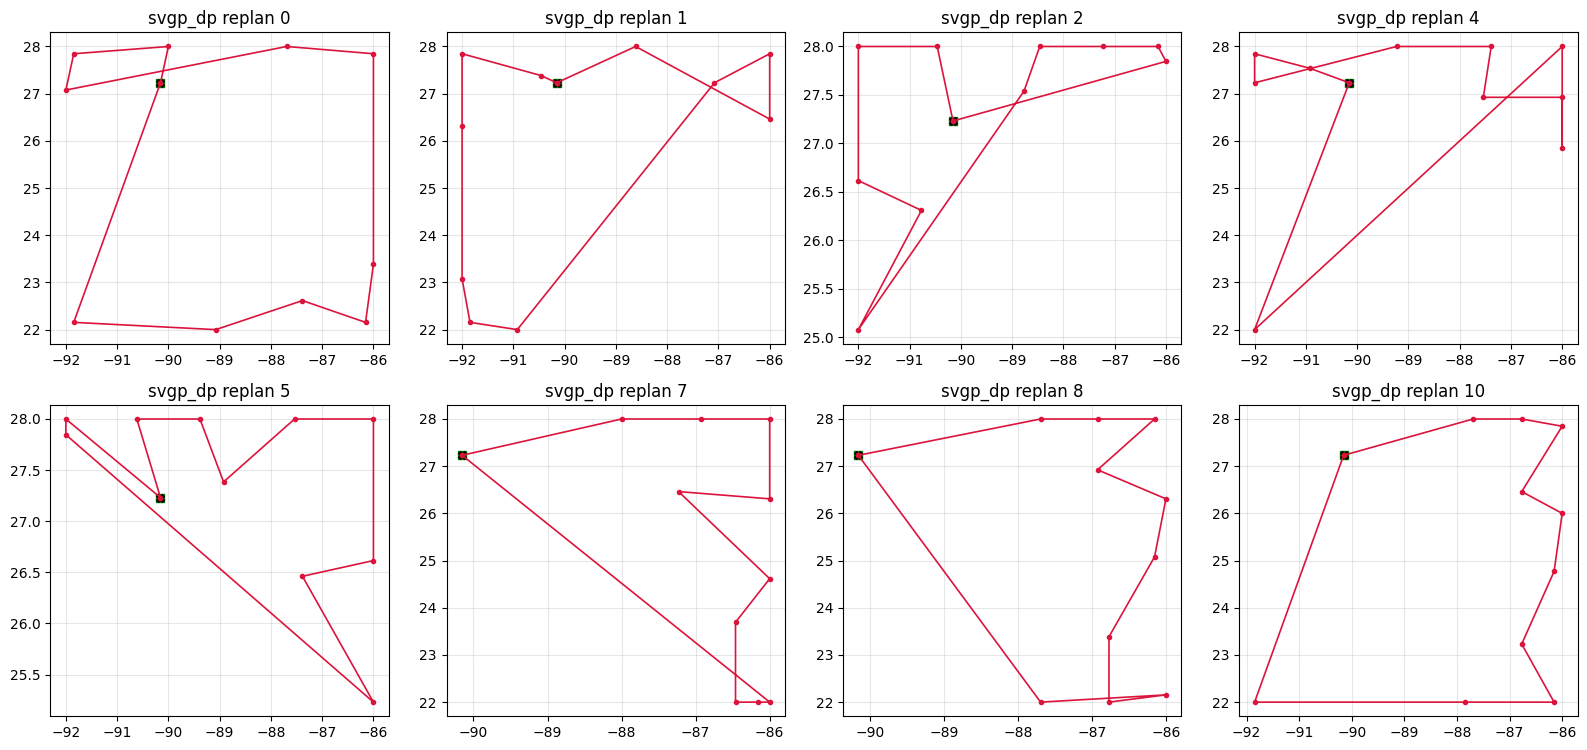

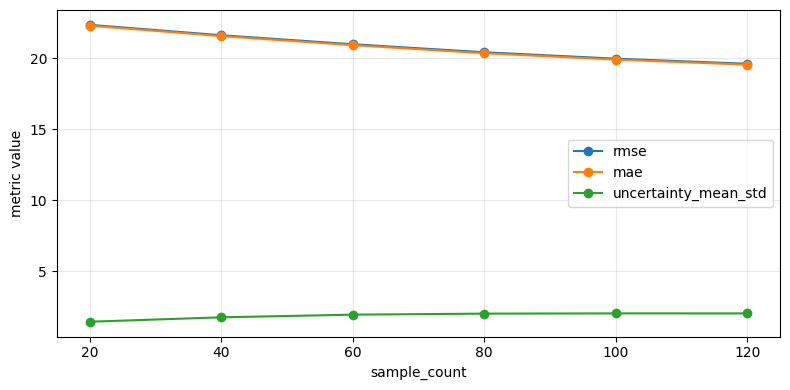

,run,rmse,mae,uncertainty_mean_std,distance,runtime,replans,samples,error
1,dynamic_default,1.879038e+01,1.867161e+01,23.086588,2.469771e+07,34.746073,11,120,None
2,sogp_dp,1.879038e+01,1.867161e+01,23.086588,2.469771e+07,34.620073,11,120,None
6,route_networkx_open,1.879038e+01,1.867161e+01,23.086588,2.469771e+07,35.132954,11,120,None
4,svgp_dp,1.960385e+01,1.953988e+01,2.042348,2.263732e+07,37.620127,11,120,None
5,svgp_greedy,1.982146e+01,1.974174e+01,2.019892,2.866476e+07,8.862765,11,120,None
0,static_default,2.453217e+01,2.448106e+01,24.546563,2.212389e+07,34.551682,11,120,None
7,route_ortools_closed,2.453425e+01,2.448352e+01,23.992341,1.780773e+07,40.934346,12,120,None
3,sogp_greedy,7.661045e+12,7.660393e+12,96.020811,1.559048e+07,7.450635,11,120,None


In [8]:
# Visualize routes + metric curves for one run
run_key = "svgp_dp" if "svgp_dp" in results else list(results.keys())[0]
run_result = results[run_key]
print("Selected run:", run_key)

routes = []
for r in run_result.get("route_history", []):
    arr = np.asarray(r.get("route_points", []), dtype=float)
    if arr.ndim == 2 and arr.shape[1] == 2 and arr.shape[0] > 0:
        routes.append(arr)

if routes:
    plot_route_sequence(routes, title_prefix=f"{run_key} replan", max_routes=8, show=True)

if run_result.get("metrics_history"):
    plot_metric_curves(run_result["metrics_history"], x_key="sample_count", show=True)

summarize_results(results)

Persistent sampling completed: samples=120 replans=11 rmse=18.790382661412252
maps_snapshot samples= 120 replans= 11 rmse= 18.790382661412252


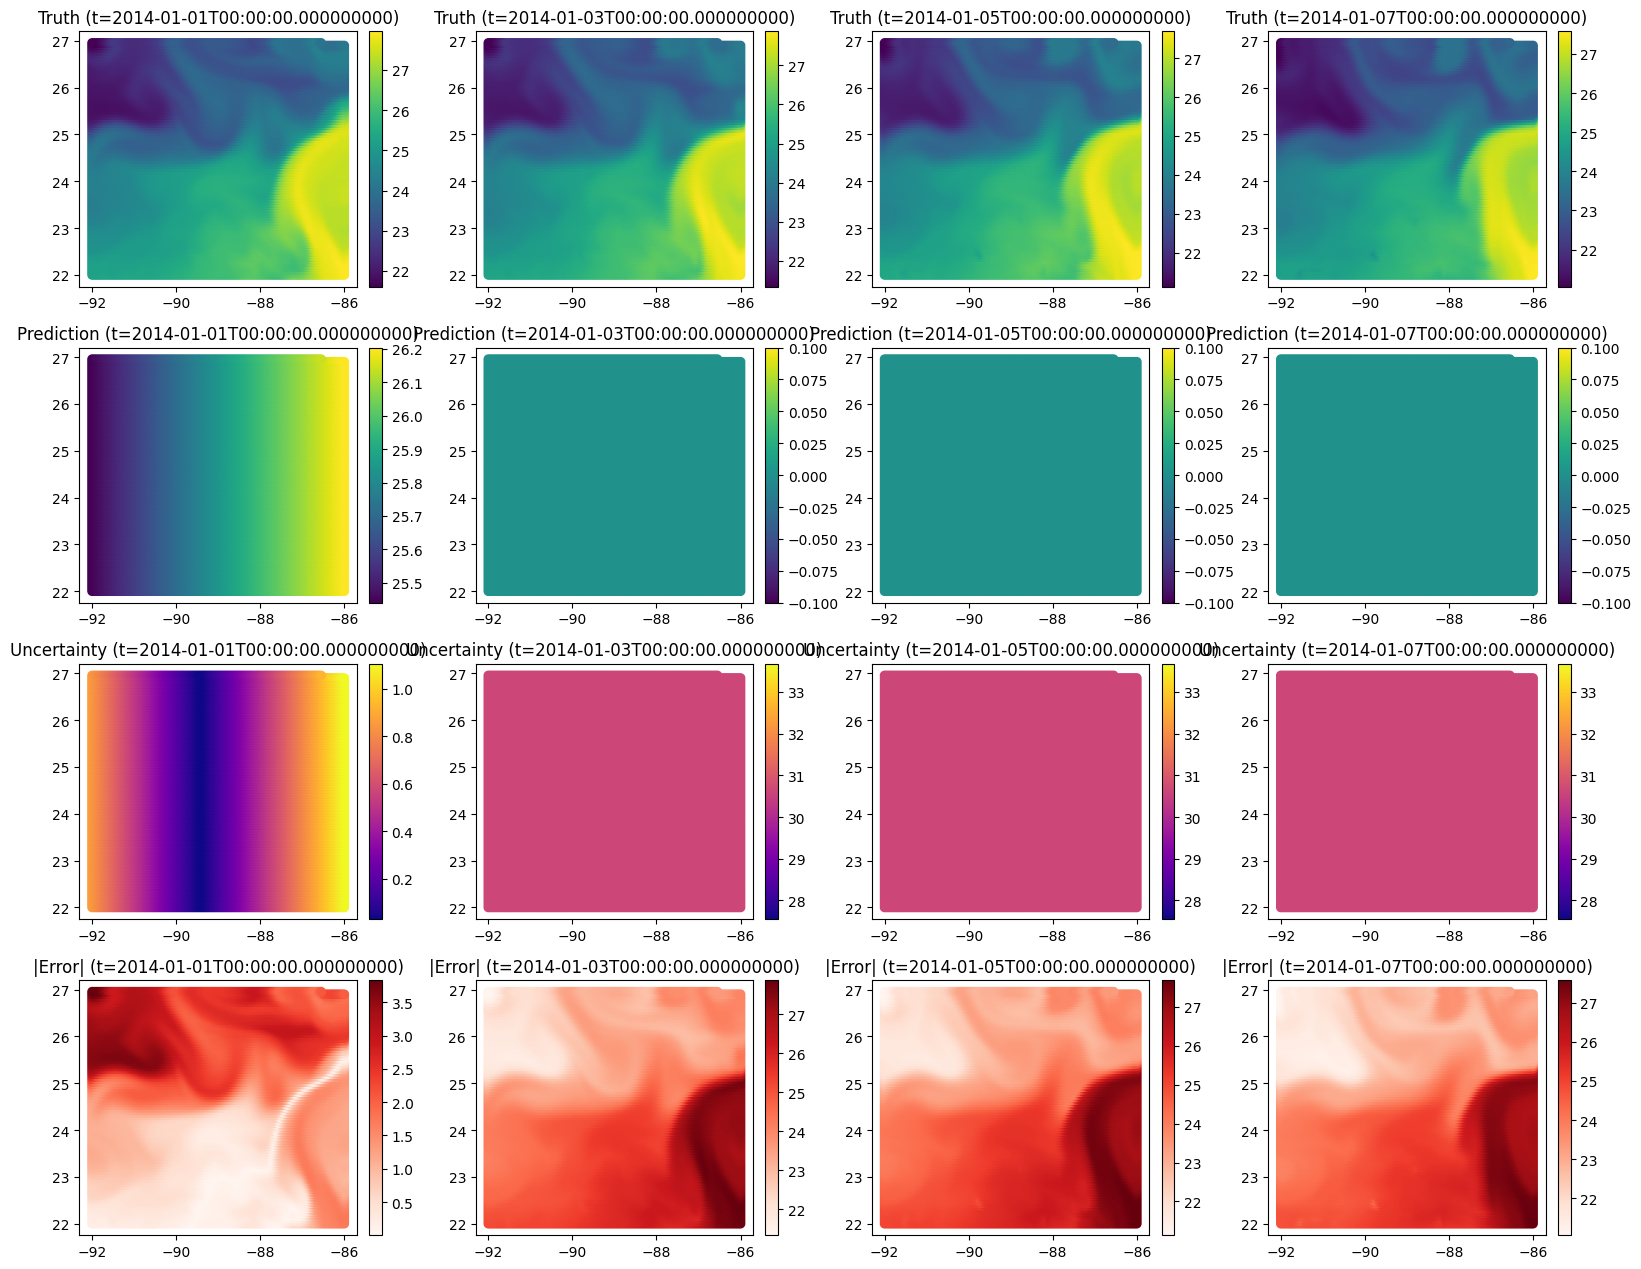

In [9]:
# Optional: run once with map snapshots and plot truth/pred/uncertainty/error over time
cfg_maps = copy.deepcopy(CONFIG)
cfg_maps["eval"]["store_maps"] = True
cfg_maps["eval"]["every_n_samples"] = cfg_maps["mission"]["max_samples"]  # capture at final checkpoint
res_maps = run_case(cfg_maps, "maps_snapshot")

if res_maps.get("metrics_history"):
    frames = res_maps["metrics_history"][-1].get("map_frames", [])
    if frames:
        lats = np.asarray(res_maps["metrics_history"][-1]["eval_spatial_lats"], dtype=float)
        lons = np.asarray(res_maps["metrics_history"][-1]["eval_spatial_lons"], dtype=float)
        truth_list = [np.asarray(f["truth"], dtype=float) for f in frames]
        pred_list = [np.asarray(f["pred"], dtype=float) for f in frames]
        std_list = [np.asarray(f["std"], dtype=float) for f in frames]
        times = [f["time"] for f in frames]
        plot_map_sequence(
            lats=lats,
            lons=lons,
            truth_list=truth_list,
            pred_list=pred_list,
            std_list=std_list,
            times=times,
            max_frames=min(6, len(frames)),
            show=True,
        )

Persistent sampling completed: samples=120 replans=11 rmse=19.603852513342165
svgp_dp_maps samples= 120 replans= 11 rmse= 19.603852513342165


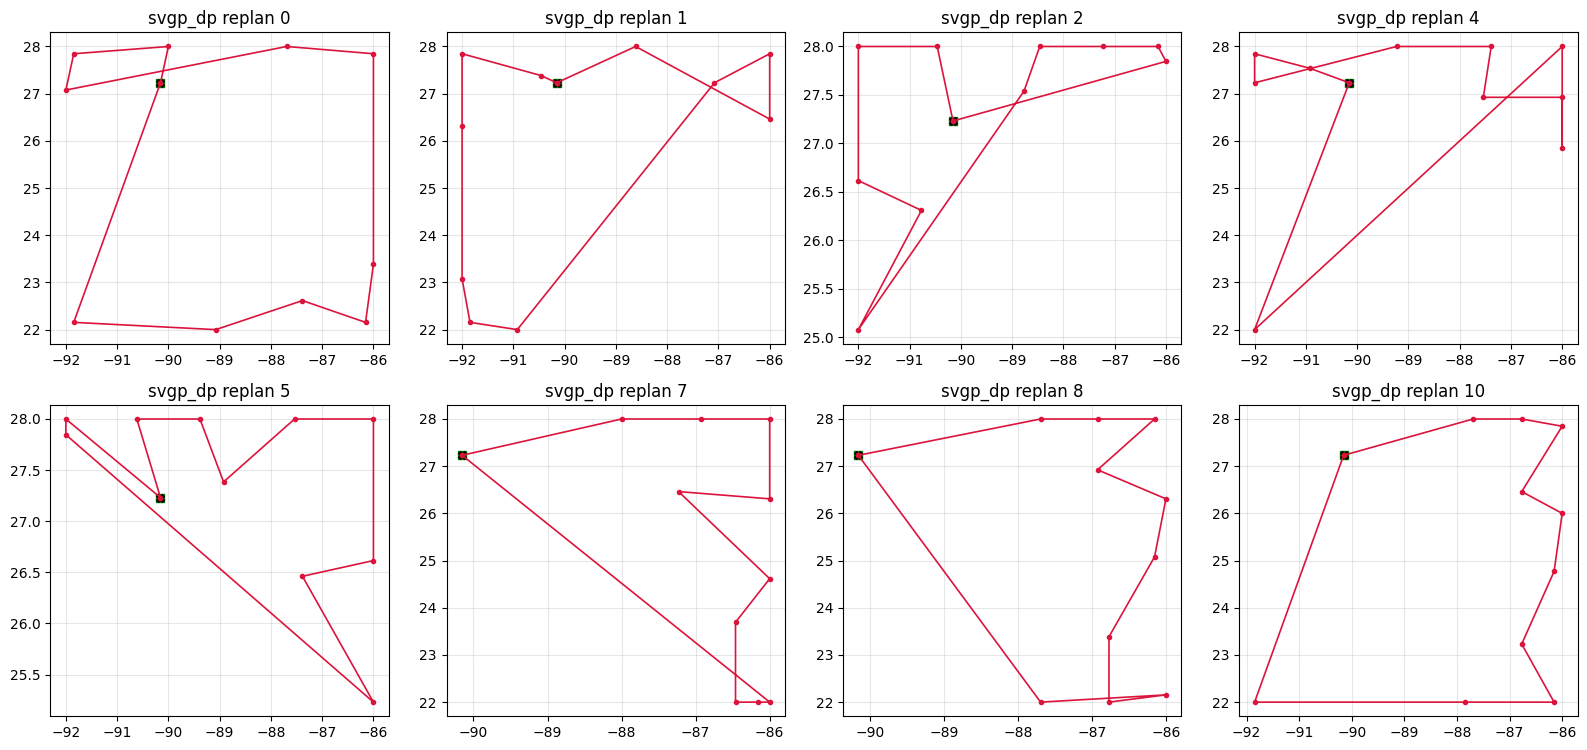

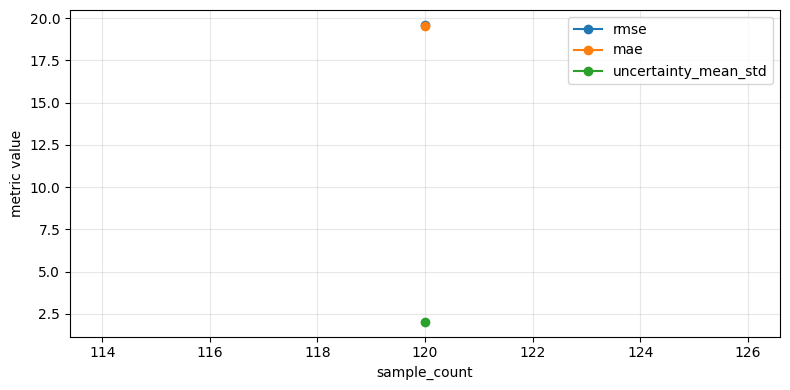

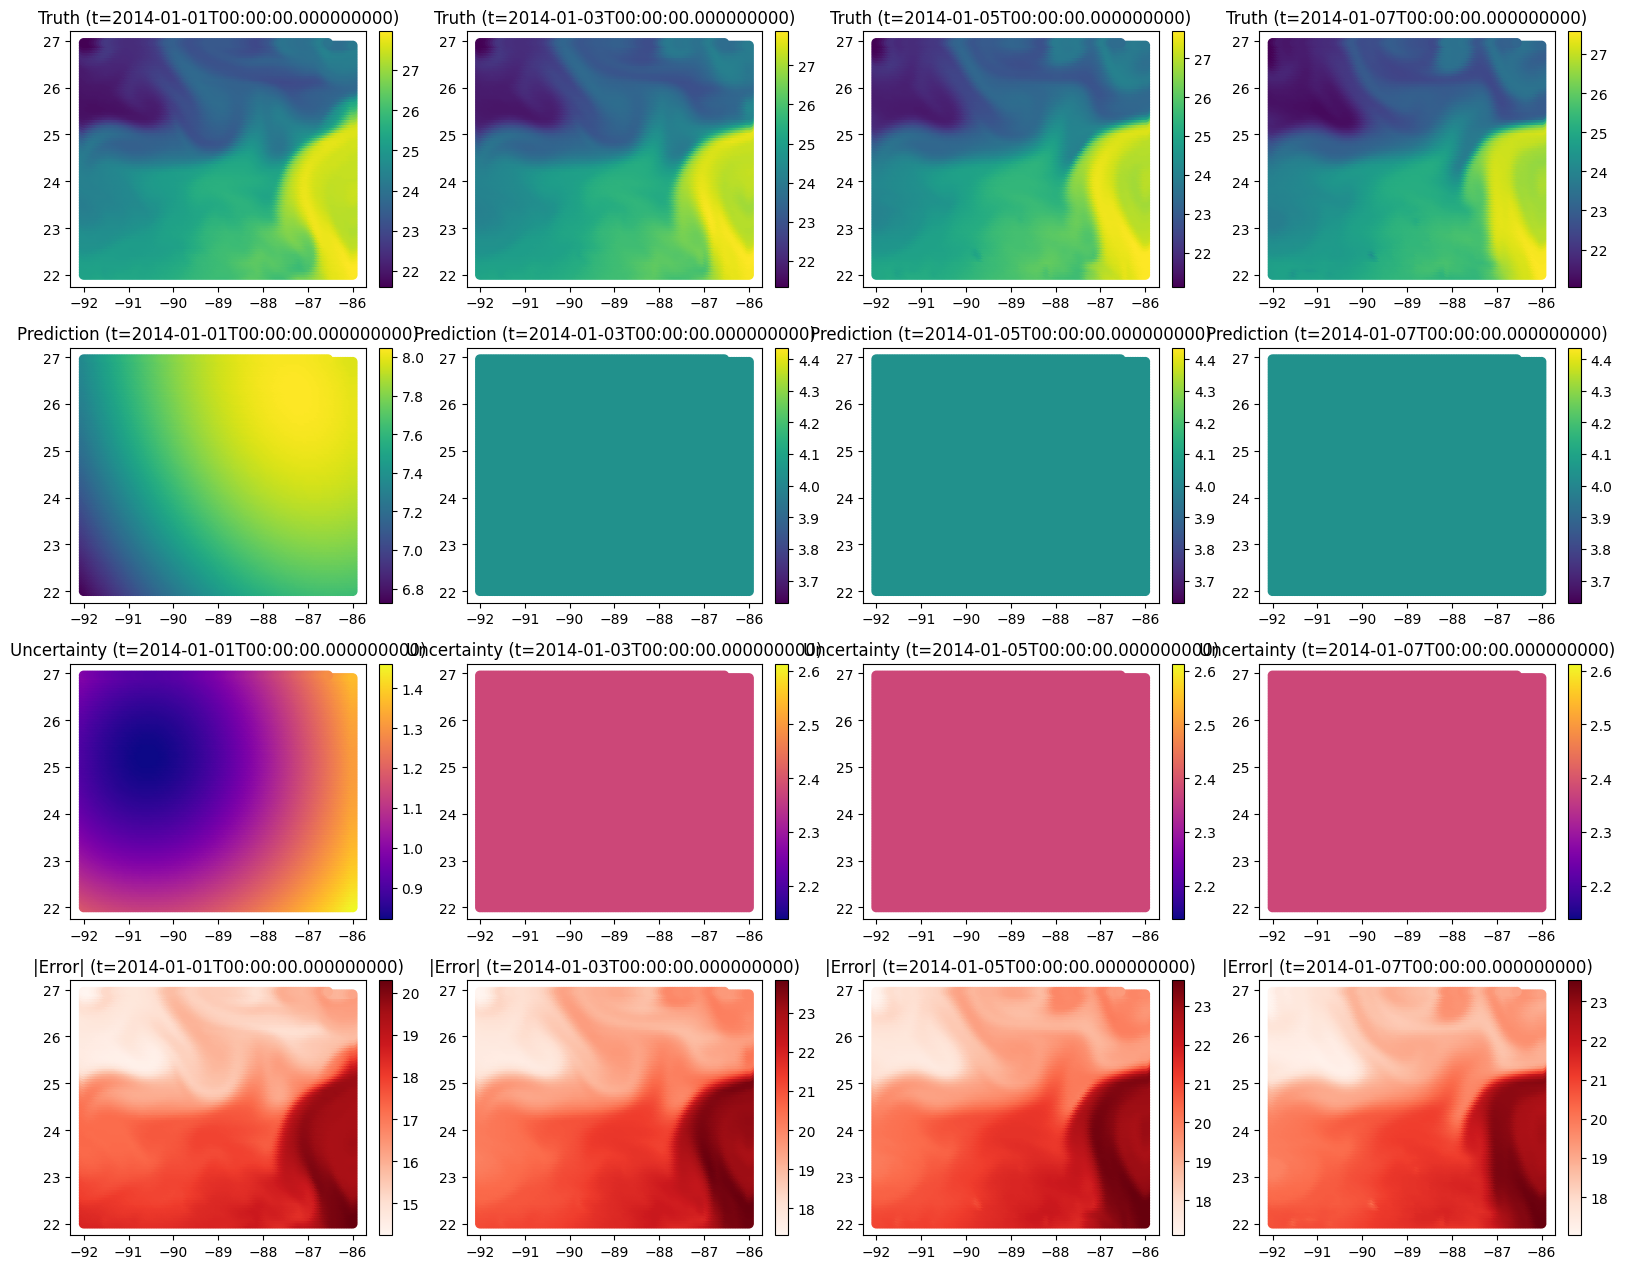

,run,rmse,mae,uncertainty_mean_std,distance,runtime,replans,samples,error
0,svgp_dp_maps,19.603853,19.539881,2.042348,2.263732e+07,37.688117,11,120,None


In [10]:
# SVGP + DP: run once and generate all plots

cfg_svgp_dp_maps = copy.deepcopy(CONFIG)
cfg_svgp_dp_maps["field_model"]["backend"] = "svgp_gpytorch"
cfg_svgp_dp_maps["planner"]["type"] = "mi_dp"
cfg_svgp_dp_maps["noise"]["mode"] = "estimate"
cfg_svgp_dp_maps["noise"]["estimate_method"] = "gp_likelihood"

# store map frames at the final checkpoint
cfg_svgp_dp_maps["eval"]["store_maps"] = True
cfg_svgp_dp_maps["eval"]["every_n_samples"] = cfg_svgp_dp_maps["mission"]["max_samples"]

res_svgp_dp = run_case(cfg_svgp_dp_maps, "svgp_dp_maps")

if res_svgp_dp.get("error"):
    raise RuntimeError(res_svgp_dp["error"])

# 1) Route plots across replans
routes = []
for r in res_svgp_dp.get("route_history", []):
    arr = np.asarray(r.get("route_points", []), dtype=float)
    if arr.ndim == 2 and arr.shape[1] == 2 and arr.shape[0] > 0:
        routes.append(arr)

if routes:
    plot_route_sequence(routes, title_prefix="svgp_dp replan", max_routes=8, show=True)

# 2) Metric curves over samples
if res_svgp_dp.get("metrics_history"):
    plot_metric_curves(res_svgp_dp["metrics_history"], x_key="sample_count", show=True)

# 3) Truth / prediction / uncertainty / error maps over time
if res_svgp_dp.get("metrics_history"):
    last = res_svgp_dp["metrics_history"][-1]
    frames = last.get("map_frames", [])
    if frames:
        lats = np.asarray(last["eval_spatial_lats"], dtype=float)
        lons = np.asarray(last["eval_spatial_lons"], dtype=float)
        truth_list = [np.asarray(f["truth"], dtype=float) for f in frames]
        pred_list  = [np.asarray(f["pred"], dtype=float) for f in frames]
        std_list   = [np.asarray(f["std"], dtype=float) for f in frames]
        times      = [f["time"] for f in frames]

        plot_map_sequence(
            lats=lats,
            lons=lons,
            truth_list=truth_list,
            pred_list=pred_list,
            std_list=std_list,
            times=times,
            max_frames=min(6, len(frames)),
            show=True,
        )

# compact summary row
summarize_results({"svgp_dp_maps": res_svgp_dp})

## Results Summary Table

Use `summarize_results(results)` to compare:

- RMSE / MAE
- uncertainty mean std
- route distance
- runtime
- number of replans
- total samples

You can copy/export the dataframe as CSV for benchmark reports.